SVM probability=TRUE 무조건!!!!!!!! 필수적임 기억해


트리계열 CRITERION
- 분류는 지니계수 기준
- 상황에 맞게...


OBJECTIVE

어떤 연구 질문에서 어떤 스코어를 내가 기준으로 봐야하는가??

AUC 를 보는 경우는 -> 임계점이 정확하게 안 정해졌을 떄, 

위험도에 대한 순위를 매기는 것....


당뇨병에서 걸린사람한테 안 결렸따고 하는게 더 안좋은거


기준이 없으면 AUC
맞은걸 틀렸따고한거, 틀린것 맞았다고 할때 어떤게 더 심각한 결과를 가져오는가?



# [LAB 09] 지도학습 > 분류 > 05.비선형 분류


## #01.준비작업
### [1] 패키지 가져오기

In [2]:
# =====================================================
# 기본 라이브러리
# =====================================================
from hossam import *

import pandas as pd
from pandas import DataFrame, Series, concat, merge
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from itertools import product


# =====================================================
# sklearn 공통
# =====================================================
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# =====================================================
# 선형 모델
# =====================================================
from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression,
    Ridge,
    Lasso,
    SGDClassifier,
    SGDRegressor
)


# =====================================================
# 기타 분류 모델
# =====================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# =====================================================
# 성능 평가 지표
# =====================================================
from sklearn.metrics import (
    log_loss,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score
)


# =====================================================
# SHAP 분석
# =====================================================
import shap


### [2] 앞서 정의한 함수
- hs_cls_bin_scores


In [3]:
def hs_cls_bin_scores(estimator, x_test, y_test):

    # 피_양성 확률
    y_pred_proba = estimator.predict_proba(x_test)

    # 1로 분류될 확률
    y_pred_proba_1 = estimator.predict_proba(x_test)[:, 1]

    # 예측값
    y_pred = estimator.predict(x_test)

    # 의사결정계수 (Pseudo R²)
    log_loss_test = -log_loss(y_test, y_pred_proba, normalize=False)
    y_null = np.ones_like(y_test) * y_test.mean()
    log_loss_null = -log_loss(y_test, y_null, normalize=False)
    pseudo_r2 = 1 - (log_loss_test / log_loss_null)

    # 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    ((TN, FP), (FN, TP)) = cm

    # 클래스 이름
    if hasattr(estimator, "named_steps"):
        classname = estimator.named_steps["model"].__class__.__name__
    else:
        classname = estimator.__class__.__name__

    # auc score
    auc = roc_auc_score(y_test, y_pred_proba_1)

    score_df = DataFrame({
        "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
        "정밀도(Precision)": [precision_score(y_test, y_pred)],
        "재현율(Recall,tpr)": [recall_score(y_test, y_pred)],
        "위양성률(Fallout,fpr)": [FP / (TN + FP)],
        "특이성(TNR)": [1 - (FP / (TN + FP))],
        "F1-Score": [f1_score(y_test, y_pred)],
        "AUC": [auc]
    }, index=[classname])

    # ------------------------------
    # ROC 곡선 그리기
    # ------------------------------

    roc_fpr, roc_tpr, thresholds = roc_curve(y_test, y_pred_proba_1)

    # 1) 그래프 초기화
    my_dpi = 100  # 그래프 해상도

    width_px = 1000   # 그래프 가로 크기
    height_px = 900   # 그래프 세로 크기
    rows = 1          # 그래프 행 수
    cols = 1          # 그래프 열 수

    figsize = (width_px / my_dpi, height_px / my_dpi)
    fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    # 2) LinePlot 그리기
    sb.lineplot(x=roc_fpr, y=roc_tpr)
    sb.lineplot(x=[0, 1], y=[0, 1], color='red', linestyle=":", alpha=0.5)
    plt.fill_between(x=roc_fpr, y1=roc_tpr, alpha=0.1)

    # 3) 그래프 꾸미기
    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC={auc:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # 4) 출력
    plt.tight_layout()
    plt.show()
    plt.close()

    return score_df


### [3] 데이터 가져오기

In [4]:
origin = load_data('pima_indians_diabetes_preprocessed')
origin.head()

캐글에서 제공하는 pima_indians_diabetes의 전처리 완료 버전(결측치 정제+로그변환) (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.946,5.004,72,3.584,4.836,3.544,0.487,3.932,1
1,0.693,4.454,66,3.401,4.836,3.318,0.301,3.466,0
2,2.197,5.215,64,3.401,4.836,3.190,0.514,3.497,1
3,0.693,4.500,66,3.178,4.554,3.371,0.154,3.091,0
4,0.000,4.927,40,3.584,5.130,3.786,1.190,3.526,1


### [4] 훈련,검증 데이터 분리

In [5]:
df = origin

# 종속변수는 정수형으로 변환해야 한다.
df['Outcome'] = df['Outcome'].astype('int')

yname = "Outcome"
x = df.drop(columns=[yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=52
)

x_train.shape, x_test.shape, y_train.shape, y_test.shape


((614, 8), (154, 8), (614,), (154,))

## #02.로지스틱 회귀 모형
- 이 예제에서는 과적합 여부 판단은 제외하여 진행

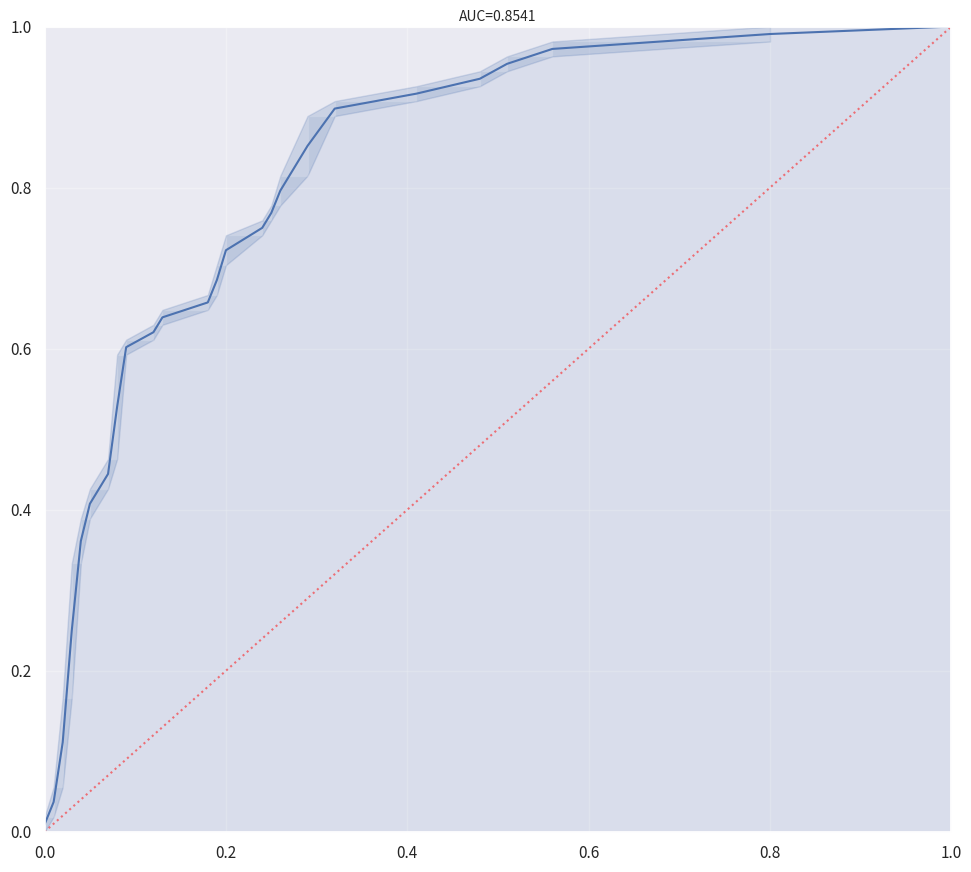

CPU times: total: 656 ms
Wall time: 6.34 s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
LogisticRegression,0.766,0.629,0.815,0.260,0.740,0.710,0.854


In [6]:
%%time

logit_pipe = Pipeline([
    ("VIF_Selector", VIFSelector()),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=52))
])

logit_param_grid = {
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__max_iter": [100, 300, 500],
    "model__class_weight": [None, "balanced"],
}

logit_gs = GridSearchCV(
    estimator=logit_pipe,
    param_grid=logit_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

logit_gs.fit(x_train, y_train)

logit_estimator = logit_gs.best_estimator_

logit_score_df = hs_cls_bin_scores(logit_estimator, x_test, y_test)
logit_score_df


## #03. 경사 하강법

| 하이퍼파라미터           | 구분 | 핵심도 | 의미        | 기본값 (sklearn)                         | 역할                       | 값 설정 가이드                                                                          |
| ----------------- | -- | --- | --------- | ------------------------------------- | ------------------------ | --------------------------------------------------------------------------------- |
| **loss**          | 분류 | ⭐⭐⭐ | 손실 함수     | `'hinge'`                             | 분류 기준 결정                 | • `'hinge'` → 선형 SVM<br>• `'log_loss'` → 로지스틱 회귀<br>• `'modified_huber'` → 이상치 강건 |
| **penalty**       | 공통 | ⭐⭐⭐ | 규제 종류     | `'l2'`                                | 적용할 규제 방식 선택             | • `'l2'` → Ridge 성향<br>• `'l1'` → Lasso 성향<br>• `'elasticnet'` → 혼합               |
| **alpha**         | 공통 | ⭐⭐⭐ | 규제 강도 (λ) | `0.0001`                              | 계수 크기 억제 수준 결정           | • 작게 → 규제 약함<br>• 크게 → 과적합 억제 강화                                                  |
| **l1_ratio**      | 공통 | ⭐⭐  | L1 비율     | `0.15`                                | elasticnet 사용 시 L1/L2 비율 | • 0 → Ridge 성향<br>• 1 → Lasso 성향                                                  |
| **max_iter**      | 공통 | ⭐⭐  | 최대 반복 횟수  | `1000`                                | 학습 반복 한계                 | • 수렴 경고 시 증가                                                                      |
| **learning_rate** | 공통 | ⭐⭐  | 학습률 전략    | 회귀: `'invscaling'`<br>분류: `'optimal'` | 학습률 감소 방식                | • 기본값 유지 권장                                                                       |
| **eta0**          | 공통 | ⭐   | 초기 학습률    | `0.0`                                 | 초기 스텝 크기                 | • `'constant'`, `'adaptive'` 설정 시 의미                                              |
| **class_weight**  | 분류 | ⭐⭐  | 클래스 가중치   | `None`                                | 불균형 데이터 보정               | • `'balanced'` 사용                                                                 |
| **random_state**  | 공통 | ✅   | 난수 시드     | `None`                                | 학습 순서 재현성                | • 실험 비교 시 고정                                                                      |
| **n_jobs**        | 공통 | ✅   | 병렬 처리 수   | `None`                                | 연산 병렬화                   | • `-1` 권장                                                                         |


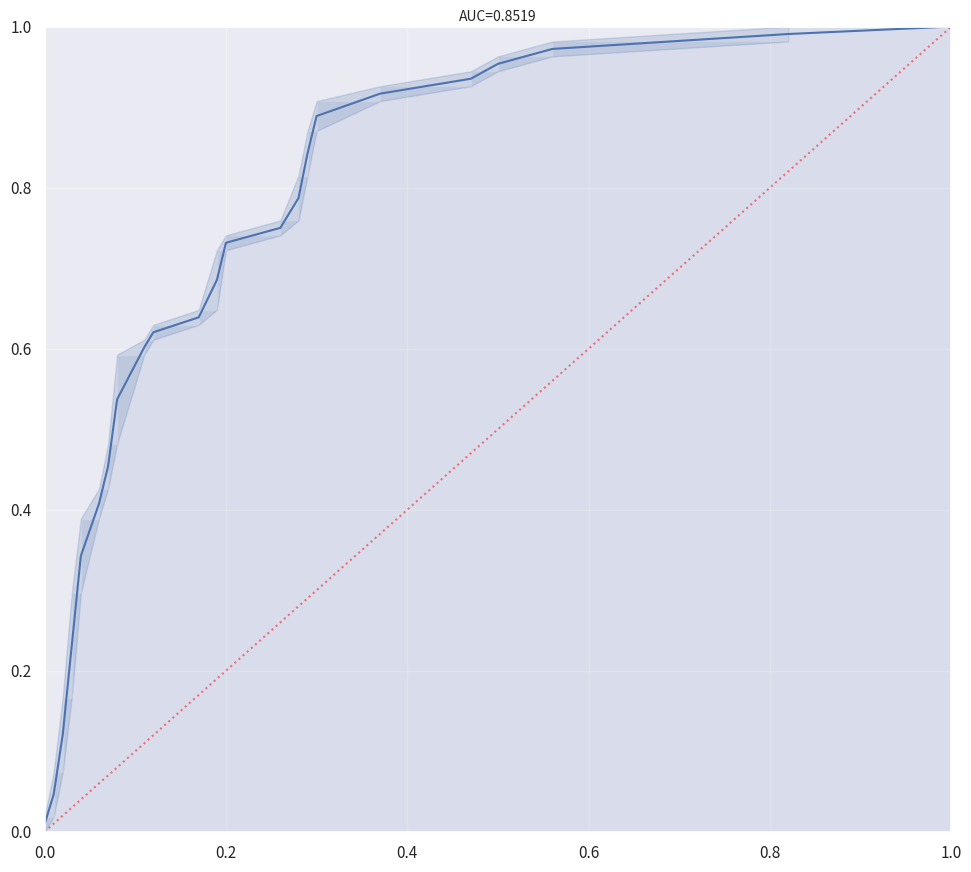

CPU times: total: 969 ms
Wall time: 2.04 s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
SGDClassifier,0.773,0.694,0.630,0.150,0.850,0.660,0.852


In [7]:
%%time

sgd_pipe = Pipeline([
    ("VIF_Selector", VIFSelector()),
    ("scaler", StandardScaler()),
    (
        "model",
        SGDClassifier(
            random_state=52,
            n_jobs=-1,
        ),
    ),
])

sgd_param_grid = {
    "model__loss": ["hinge", "log_loss", "modified_huber"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [0.01, 0.1, 1, 10, 100],  # C의 역수 대응
    "model__max_iter": [1000, 2000, 5000],
    "model__class_weight": [None, "balanced"],
}

sgd_gs = GridSearchCV(
    estimator=sgd_pipe,
    param_grid=sgd_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

sgd_gs.fit(x_train, y_train)

sgd_estimator = sgd_gs.best_estimator_

sgd_score_df = hs_cls_bin_scores(sgd_estimator, x_test, y_test)

sgd_score_df


## #04. KNN

## KNeighborsClassifier 주요 하이퍼파라미터

| 파라미터명 | 구분 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장값 |
|------------|------|--------|------|--------|--------------------|
| n_neighbors | 공통 | ⭐⭐⭐ | 이웃 수 k (bias-variance 절제) | 5 | [3, 5, 7, 9, 15, 25] |
| weights | 공통 | ⭐⭐ | 이웃 가중치 방식 | 'uniform' | ['uniform', 'distance'] |
| metric | 공통 | ⭐⭐ | 거리 계산 방식 | 'minkowski' | ['euclidean', 'manhattan', 'minkowski'] |
| p | 공통 | ⭐⭐ | Minkowski 거리 차수 | 2 | [1, 2] |
| algorithm | 공통 | ⭐ | 최근접 탐색 알고리즘 | 'auto' | ['auto', 'ball_tree', 'kd_tree'] |
| leaf_size | 공통 | ⭐ | 트리 노드 크기 | 30 | [20, 30, 40] |
| n_jobs | 공통 | ✅ | 병렬 처리 수 | None | -1 |
| weights (확률) | 분류 | ⭐⭐ | 클래스 확률 계산 영향 | 'uniform' | 'distance' 권장 |


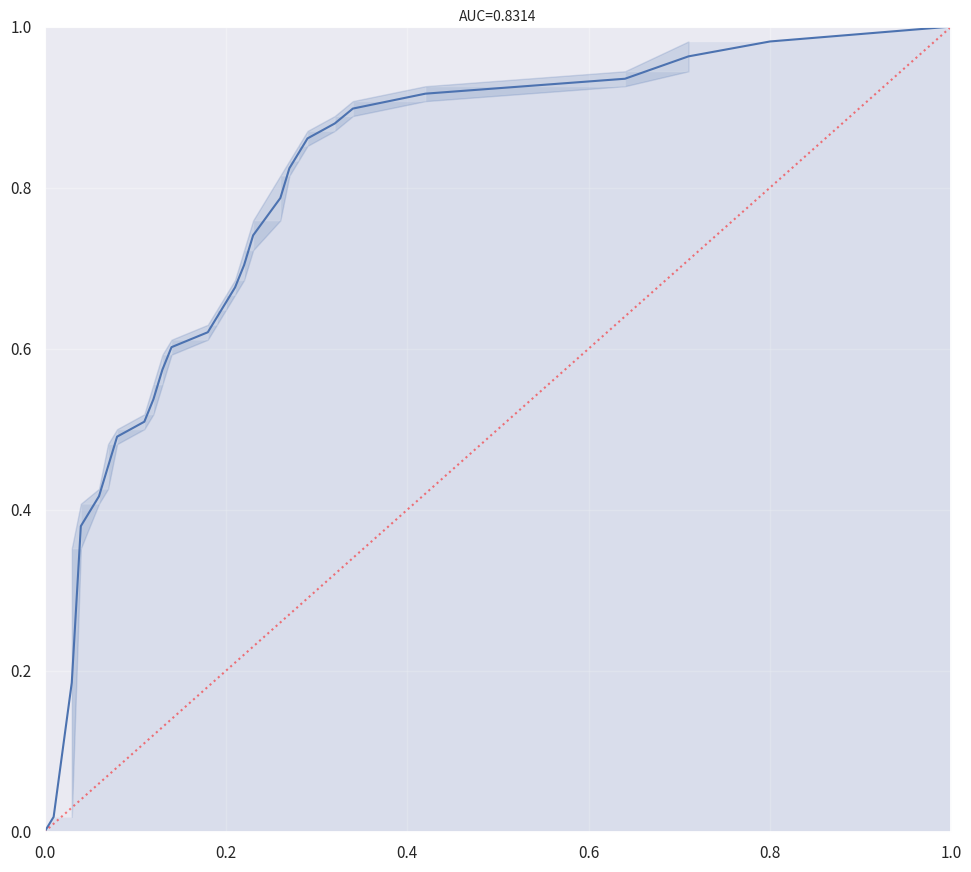

CPU times: total: 422 ms
Wall time: 1.21 s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
KNeighborsClassifier,0.747,0.642,0.630,0.190,0.810,0.636,0.831


In [8]:
%%time

knn_cls_pipe = Pipeline([
    ("scaler", StandardScaler()),  # 거리기반 → 필수
    (
        "model",
        KNeighborsClassifier(n_jobs=-1)
    ),
])

knn_cls_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 15, 25],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan", "minkowski"],
    "model__p": [1, 2],
    "model__weights": ["uniform", "distance"],
}

knn_cls_gs = GridSearchCV(
    estimator=knn_cls_pipe,
    param_grid=knn_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

knn_cls_gs.fit(x_train, y_train)

knn_cls_estimator = knn_cls_gs.best_estimator_

knn_cls_score_df = hs_cls_bin_scores(
    knn_cls_estimator,
    x_test,
    y_test
)

knn_cls_score_df


## #05. SVM

| 파라미터명          | 구분 | 핵심도 | 설명                               | 기본값       | GridSearchCV 권장값                  |
| -------------- | -- | --- | -------------------------------- | --------- | --------------------------------- |
| `kernel`       | 공통 | ⭐⭐⭐ | 커널 종류 (비선형 표현 방식)                | `'rbf'`   | `['linear', 'rbf', 'poly']`       |
| `C`            | 공통 | ⭐⭐⭐ | 오차 패널티 강도 (bias-variance 조절)     | `1.0`     | `[0.1, 1, 10, 100]`               |
| `epsilon`      | 예측 | ⭐⭐  | ε-튜브 폭 (오차 허용 범위, SVR용)          | `0.1`     | `[0.01, 0.05, 0.1, 0.2, 0.5]`     |
| `gamma`        | 공통 | ⭐⭐⭐ | 데이터 1개 영향 범위 (RBF/Poly)          | `'scale'` | `['scale', 'auto', 0.01, 0.1, 1]` |
| `degree`       | 공통 | ⭐⭐  | 다항 커널 차수 (`kernel='poly'`일 때 의미) | `3`       | `[2, 3, 4]`                       |
| `coef0`        | 공통 | ⭐   | 다항·시그모이드 커널 보정항                  | `0.0`     | `[0.0, 0.5, 1.0]`                 |
| `shrinking`    | 공통 | ⭐   | 최적화 속도 개선 옵션                     | `True`    | `[True, False]`                   |
| `tol`          | 공통 | ⭐   | 수렴 허용 오차                         | `1e-3`    | `[1e-4, 1e-3]`                    |
| `max_iter`     | 공통 | ✅   | 최대 반복 횟수                         | `-1`      | `-1`                              |
| `cache_size`   | 공통 | ✅   | 커널 캐시 메모리(MB)                    | `200`     | `200`                             |
| `class_weight` | 분류 | ⭐⭐  | 클래스 불균형 보정                       | `None`    | `[None, 'balanced']`              |


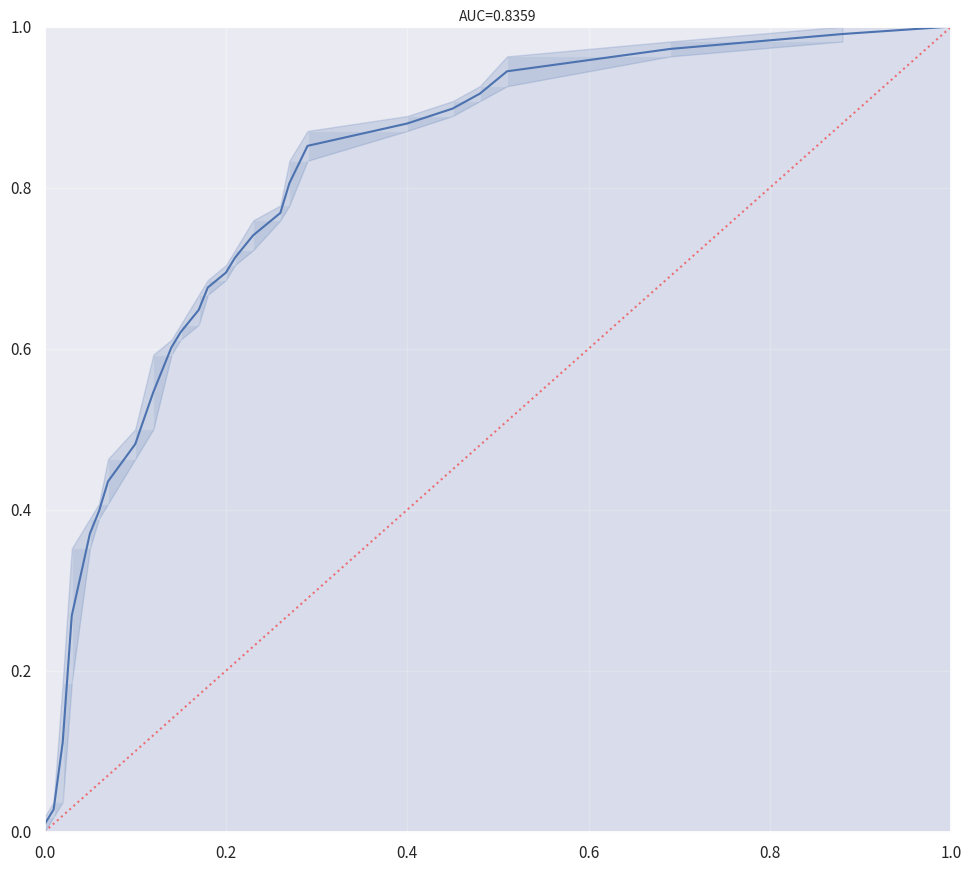

CPU times: total: 609 ms
Wall time: 3.44 s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
SVC,0.753,0.608,0.833,0.290,0.710,0.703,0.836


In [9]:
%%time

svc_pipe = Pipeline([
    ("scaler", StandardScaler()),   # SVM은 스케일링 필수
    ("model", SVC(
        random_state=52,
        cache_size=200,
        probability=True   # ROC_AUC 계산 위해 필요
    ))
])

svc_param_grid = {
    "model__kernel": ["rbf"],                 # 기본은 rbf 권장
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "model__degree": [2, 3, 4],               # poly일 때만 의미 있음
    "model__class_weight": [None, "balanced"]
}

svc_gs = GridSearchCV(
    estimator=svc_pipe,
    param_grid=svc_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

svc_gs.fit(x_train, y_train)

svc_estimator = svc_gs.best_estimator_
svc_estimator


svc_score_df = hs_cls_bin_scores(
    svc_estimator,
    x_test,
    y_test
)

svc_score_df


## #06. 랜덤 포레스트

## RandomForestClassifier 주요 하이퍼파라미터 (통합)

| 파라미터명 | 구분 | 핵심도 | 실무 조정 전략 요약 | 기본값(회귀/분류) | GridSearchCV 실무 권장값 |
|---|---|---|---|---|---|
| n_estimators | 공통 | ⭐⭐ | 성능 안정화용, 과도한 탐색 불필요 | 100 | [300, 500] |
| max_depth | 공통 | ⭐⭐ | 과적합 보정에 핵심 | None | [None, 10] |
| min_samples_leaf | 공통 | ⭐⭐⭐ | 과적합 방지에 핵심 | 1 | [5, 10] |
| max_features | 공통 | ⭐⭐⭐ | 트리 다양성 핵심 | 회귀: 1.0 / 분류: 'sqrt' | ['sqrt', 1.0] |
| criterion | 구분별 | ⭐ | 분할 품질 기준 | 회귀: 'squared_error' / 분류: 'gini' | 회귀: ['squared_error', 'absolute_error'] / 분류: ['gini', 'entropy'] |
| class_weight | 분류 | ⭐⭐ | 클래스 불균형 대응 | None | [None, 'balanced'] |
| n_jobs | 공통 | ✅ | 병렬 처리 | None | -1 |
| random_state | 공통 | ✅ | 재현성 확보 | None | 52 |


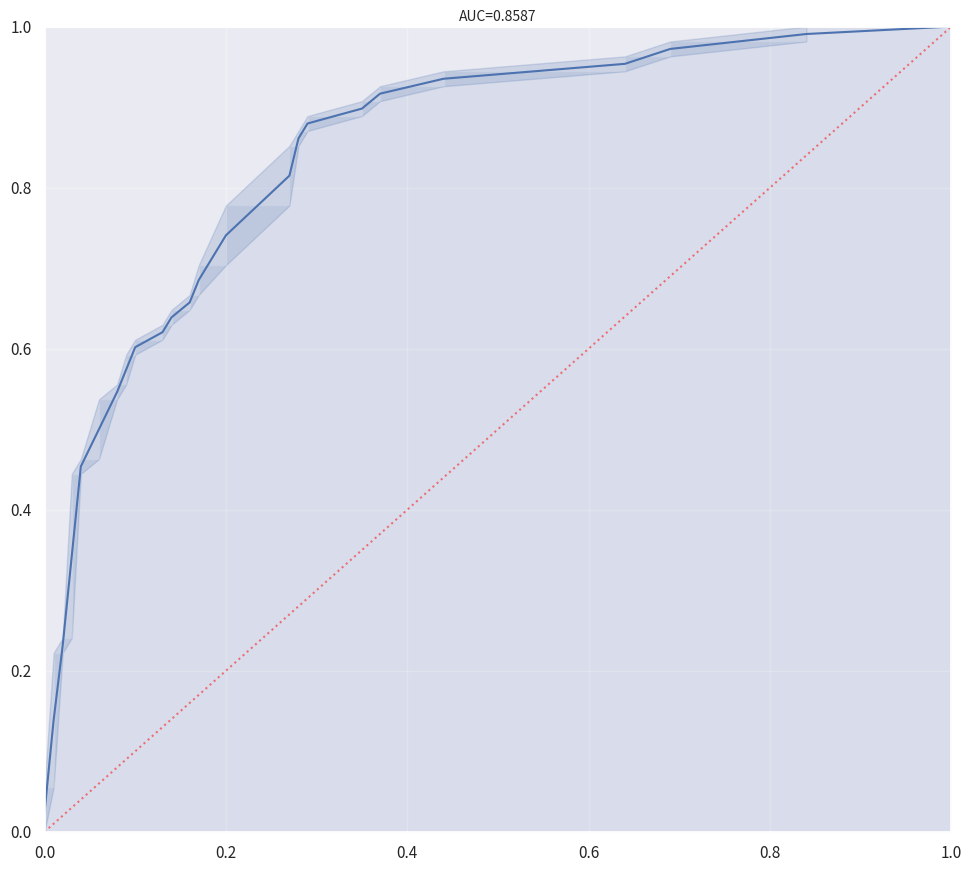

CPU times: total: 1.91 s
Wall time: 23.5 s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
RandomForestClassifier,0.747,0.609,0.778,0.270,0.730,0.683,0.859


In [10]:
%%time

rf_cls_pipe = Pipeline([
    (
        "model",
        RandomForestClassifier(
            random_state=52,
            n_jobs=-1,
        ),
    )
])

rf_cls_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}

rf_cls_gs = GridSearchCV(
    estimator=rf_cls_pipe,
    param_grid=rf_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)

rf_cls_gs.fit(x_train, y_train)

rf_cls_estimator = rf_cls_gs.best_estimator_

rf_cls_score_df = hs_cls_bin_scores(
    rf_cls_estimator,
    x_test,
    y_test
)

rf_cls_score_df


## #07 XGBoost

| 파라미터명            | 구분  | 핵심도 | 설명             | 기본값 (분류)        | GridSearchCV 권장값            |
| ---------------- | --- | --- | -------------- | --------------- | --------------------------- |
| n_estimators     | 공통  | ⭐⭐⭐ | 부스팅 트리 개수      | 100             | [100, 300, 500, 800]        |
| learning_rate    | 공통  | ⭐⭐⭐ | 학습률 (각 트리 영향력) | 0.3             | [0.01, 0.05, 0.1, 0.2, 0.3] |
| max_depth        | 공통  | ⭐⭐⭐ | 개별 트리 깊이       | 6               | [3, 5, 7, 10]               |
| min_child_weight | 공통  | ⭐⭐⭐ | 리프 노드 최소 가중치   | 1               | [1, 5, 10, 20]              |
| gamma            | 공통  | ⭐⭐  | 분기 최소 손실 감소량   | 0               | [0, 0.1, 0.5, 1, 5]         |
| subsample        | 공통  | ⭐⭐  | 행 샘플링 비율       | 1.0             | [0.6, 0.8, 1.0]             |
| colsample_bytree | 공통  | ⭐⭐  | 열 샘플링 비율       | 1.0             | [0.6, 0.8, 1.0]             |
| reg_alpha        | 공통  | ⭐⭐  | L1 정규화         | 0               | [0, 0.1, 1, 10]             |
| reg_lambda       | 공통  | ⭐⭐  | L2 정규화         | 1               | [1, 5, 10, 50]              |
| objective        | 구분별 | ✅   | 손실 함수          | binary:logistic | 고정                          |
| scale_pos_weight | 분류  | ⭐⭐  | 클래스 불균형 조정     | 1               | [1, 2, 5, 10]               |
| random_state     | 공통  | ✅   | 재현성 확보         | None            | 52                          |
| n_jobs           | 공통  | ✅   | 병렬 처리          | -1              | -1                          |


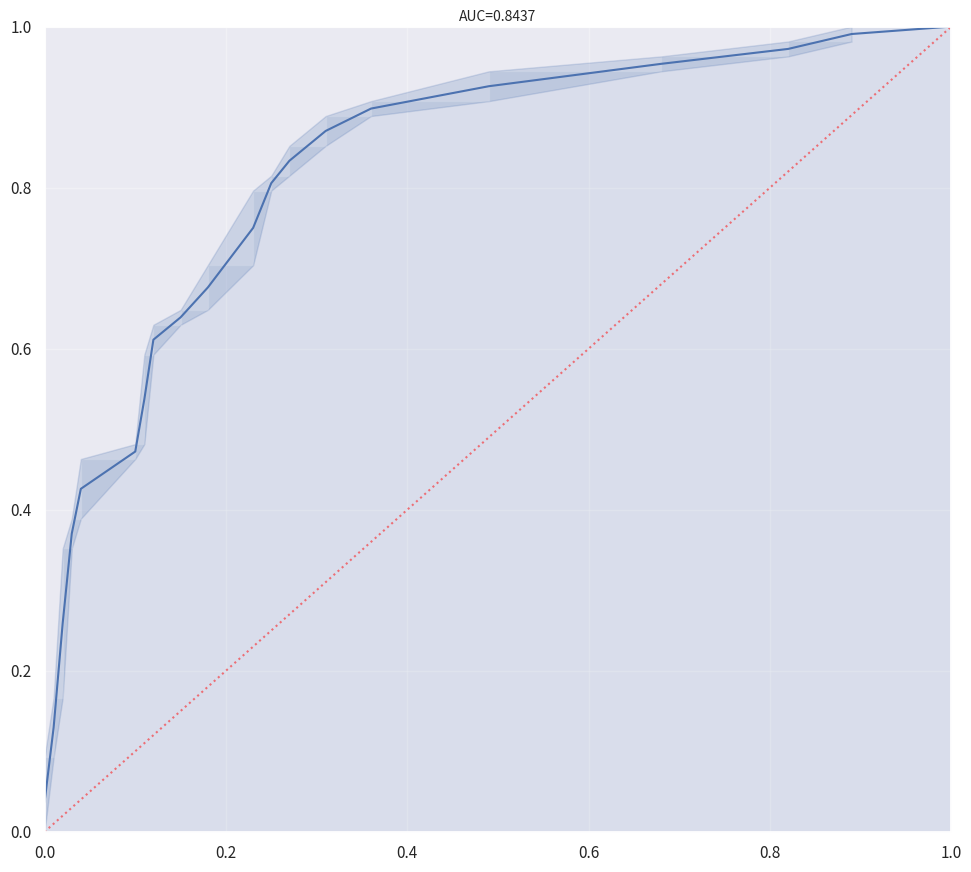

CPU times: total: 2min 29s
Wall time: 29min 2s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
XGBClassifier,0.766,0.622,0.852,0.280,0.720,0.719,0.844


In [11]:
%%time

from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 1️⃣ 파이프라인
xgb_cls_pipe = Pipeline([
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            random_state=52,
            n_jobs=-1,
            eval_metric="logloss"
        )
    )
])

# 2️⃣ 하이퍼파라미터 범위
xgb_cls_param_grid = {
    "model__n_estimators": [100, 300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 5, 10],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 5, 10],
    "model__scale_pos_weight": [1, 2, 5]
}

# 3️⃣ GridSearch
xgb_cls_gs = GridSearchCV(
    estimator=xgb_cls_pipe,
    param_grid=xgb_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# 4️⃣ 학습
xgb_cls_gs.fit(x_train, y_train)

# 5️⃣ 최적 모델
xgb_cls_estimator = xgb_cls_gs.best_estimator_

# 6️⃣ 성능 평가
xgb_cls_score_df = hs_cls_bin_scores(
    xgb_cls_estimator,
    x_test,
    y_test
)

xgb_cls_score_df


## #08. LightGBM

| 파라미터명 | 구분 | 핵심도 | 설명 | 기본값 | GridSearchCV 권장값 |
|------------|------|--------|------|--------|---------------------|
| n_estimators | 공통 | ⭐⭐⭐ | 부스팅 트리 개수 | 100 | [100, 300] |
| learning_rate | 공통 | ⭐⭐⭐ | 각 트리 기여도 | 0.1 | [0.01, 0.05, 0.1] |
| num_leaves | 공통 | ⭐⭐⭐ | 리프 개수 (복잡도 핵심) | 31 | [15, 31, 63] |
| max_depth | 공통 | ⭐⭐ | 최대 깊이 (leaf-wise 과적합 제어) | -1 | [-1, 3, 5, 7] |
| min_child_samples | 공통 | ⭐⭐ | 리프 최소 샘플 수 | 20 | [10, 20, 50, 100] |
| min_child_weight | 공통 | ⭐⭐ | 리프 최소 가중치 합 | 1e-3 | [1e-3, 1e-2, 1e-1] |
| subsample | 공통 | ⭐⭐ | 행 샘플링 비율 | 1.0 | [0.6, 0.8, 1.0] |
| subsample_freq | 공통 | ⭐ | subsample 적용 빈도 | 0 | [0, 1] |
| reg_alpha | 공통 | ⭐⭐ | L1 정규화 | 0.0 | [0, 0.1, 1] |
| reg_lambda | 공통 | ⭐⭐ | L2 정규화 | 0.0 | [0, 1, 5, 10] |
| objective | 구분별 | ⭐ | 손실 함수 | binary | 고정 |
| random_state | 공통 | ✅ | 재현성 시드 | None | 52 |
| n_jobs | 공통 | ✅ | 병렬 처리 | -1 | -1 |


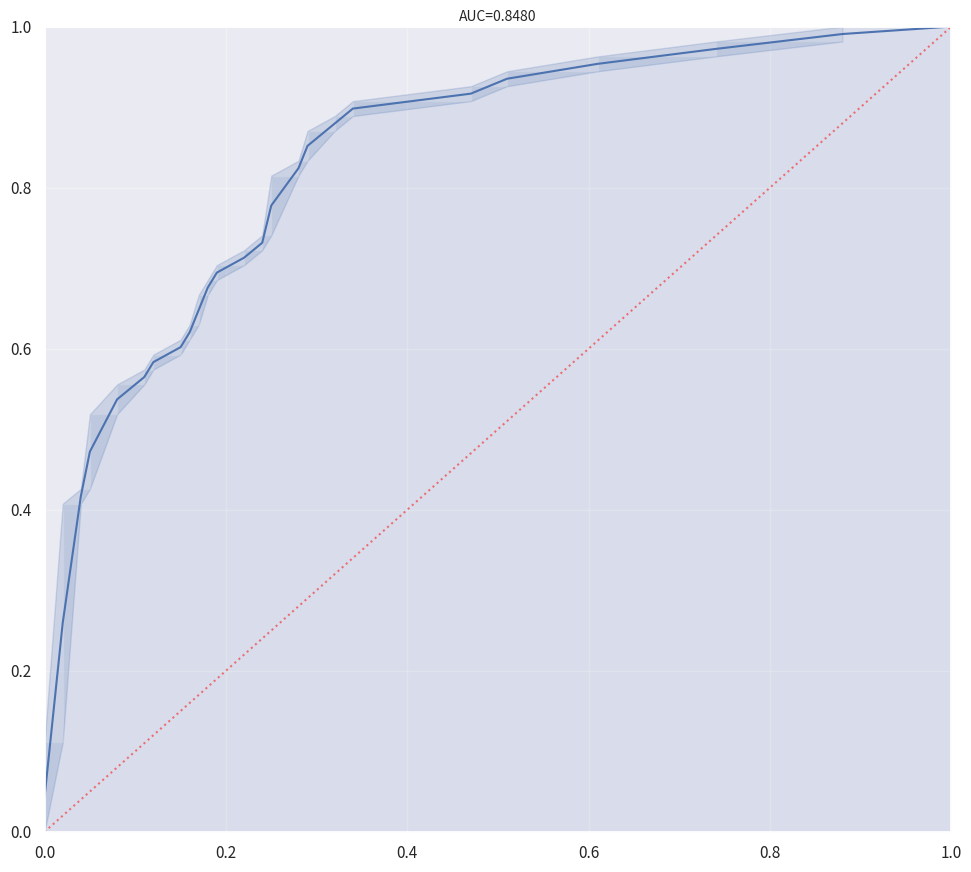

CPU times: total: 47 s
Wall time: 17min 39s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
LGBMClassifier,0.766,0.680,0.630,0.160,0.840,0.654,0.848


In [12]:
%%time

lgbm_cls_pipe = Pipeline([
    (
        "model",
        LGBMClassifier(
            objective="binary",
            random_state=52,
            n_jobs=-1,
            verbose=-1
        )
    )
])

lgbm_cls_param_grid = {
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 3, 5, 7],
    "model__min_child_samples": [10, 20, 50],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [0, 1, 5],
}

lgbm_cls_gs = GridSearchCV(
    estimator=lgbm_cls_pipe,
    param_grid=lgbm_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lgbm_cls_gs.fit(x_train, y_train)

lgbm_cls_estimator = lgbm_cls_gs.best_estimator_

lgbm_cls_score_df = hs_cls_bin_scores(
    lgbm_cls_estimator,
    x_test,
    y_test
)

lgbm_cls_score_df


## #09. CatBoost

| 파라미터명                 | 구분  | 핵심도 | 설명                    | 기본값 (분류) | GridSearchCV 권장값          |
| --------------------- | --- | --- | --------------------- | -------- | ------------------------- |
| iterations            | 공통  | ⭐⭐⭐ | 부스팅 트리 개수             | 1000     | [300, 500, 800, 1000]     |
| learning_rate         | 공통  | ⭐⭐⭐ | 각 트리 학습률              | 0.03     | [0.01, 0.03, 0.1]         |
| depth                 | 공통  | ⭐⭐⭐ | 트리 깊이                 | 6        | [4, 6, 8, 10]             |
| l2_leaf_reg           | 공통  | ⭐⭐⭐ | L2 정규화 강도             | 3.0      | [1, 3, 5, 10]             |
| min_data_in_leaf      | 공통  | ⭐⭐  | 리프 최소 샘플 수            | 1        | [1, 10, 30, 50]           |
| subsample             | 공통  | ⭐⭐  | 행 샘플링 비율              | 1.0      | [0.6, 0.8, 1.0]           |
| rsm                   | 공통  | ⭐⭐  | 열 샘플링 비율              | 1.0      | [0.6, 0.8, 1.0]           |
| loss_function         | 구분별 | ⭐⭐  | 손실 함수                 | Logloss  | 고정                        |
| eval_metric           | 구분별 | ⭐   | 평가 지표                 | AUC      | 고정                        |
| bootstrap_type        | 공통  | ⭐⭐  | 샘플링 방식                | Bayesian | ['Bayesian', 'Bernoulli'] |
| bagging_temperature   | 공통  | ⭐⭐  | Bayesian bootstrap 강도 | 1.0      | [0, 1, 5]                 |
| random_strength       | 공통  | ⭐⭐  | 분기 랜덤성                | 1.0      | [0, 1, 5]                 |
| early_stopping_rounds | 공통  | ⭐⭐  | 조기 종료                 | None     | [50, 100]                 |
| cat_features          | 공통  | ⭐⭐⭐ | 범주형 변수 지정             | None     | 데이터 의존                    |
| random_state          | 공통  | ✅   | 재현성 시드                | None     | 52                        |
| thread_count          | 공통  | ✅   | 병렬 처리                 | -1       | -1                        |


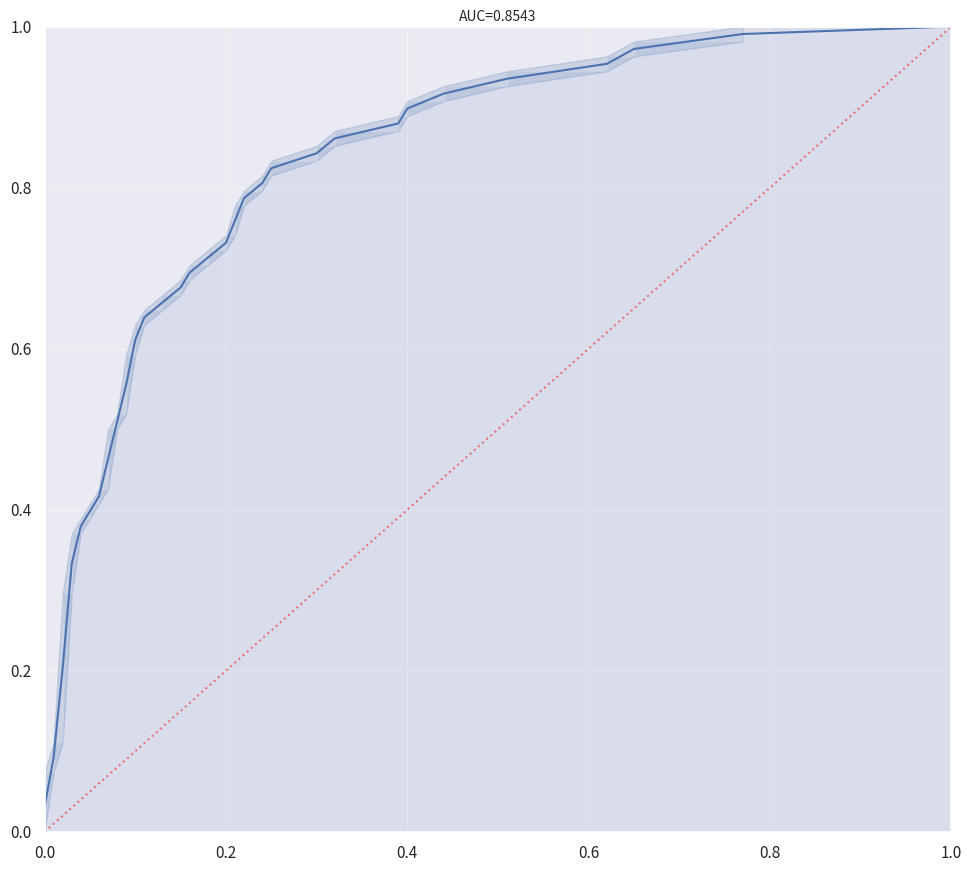

CPU times: total: 3.78 s
Wall time: 1min 18s


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
CatBoostClassifier,0.805,0.761,0.648,0.110,0.890,0.700,0.854


In [13]:
%%time

cat_cls_pipe = Pipeline([
    (
        "model",
        CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            cat_features=(),   # 범주형 변수 index 또는 컬럼명
            random_state=52,
            thread_count=-1,
            verbose=0
        )
    ),
])

cat_cls_param_grid = [

    # 🔵 Bayesian bootstrap (subsample 제거)
    {
        "model__bootstrap_type": ["Bayesian"],
        "model__iterations": [300, 500],
        "model__learning_rate": [0.01, 0.03],
        "model__depth": [4, 6],
        "model__l2_leaf_reg": [1, 3],
        "model__rsm": [0.6, 1.0],
    },

    # 🔵 Bernoulli bootstrap (subsample 포함)
    {
        "model__bootstrap_type": ["Bernoulli"],
        "model__iterations": [300, 500],
        "model__learning_rate": [0.01, 0.03],
        "model__depth": [4, 6],
        "model__l2_leaf_reg": [1, 3],
        "model__subsample": [0.6, 1.0],
        "model__rsm": [0.6, 1.0],
    },
]

cat_cls_gs = GridSearchCV(
    estimator=cat_cls_pipe,
    param_grid=cat_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

cat_cls_gs.fit(x_train, y_train)

cat_cls_estimator = cat_cls_gs.best_estimator_

cat_cls_score_df = hs_cls_bin_scores(
    cat_cls_estimator,
    x_test,
    y_test
)

cat_cls_score_df


## #10. 결과 정리

### 📌 AUC를 우선으로 고려해야 하는 경우

✔ **누가 더 위험한지 순위를 매기는 문제**

- 임계값이 아직 정해지지 않은 문제  
  - 신용 위험 점수 모델  
  - 질병 위험 예측  
  - 고객 이탈 확률 예측  

- 클래스 불균형이 큰 문제  
  - 사기 탐지 (0.1%)  
  - 고장 탐지  

- 비용이 상황에 따라 변하는 문제  
  - 마케팅 캠페인 타겟 선정  
  - 보험 리스크 평가  

In [14]:
result_df = concat([
    logit_score_df, sgd_score_df, knn_cls_score_df, svc_score_df,
    rf_cls_score_df, xgb_cls_score_df, lgbm_cls_score_df, cat_cls_score_df
])

result_df.sort_values('AUC', ascending=False, inplace=True)
result_df



,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
RandomForestClassifier,0.747,0.609,0.778,0.270,0.730,0.683,0.859
CatBoostClassifier,0.805,0.761,0.648,0.110,0.890,0.700,0.854
LogisticRegression,0.766,0.629,0.815,0.260,0.740,0.710,0.854
SGDClassifier,0.773,0.694,0.630,0.150,0.850,0.660,0.852
LGBMClassifier,0.766,0.680,0.630,0.160,0.840,0.654,0.848
XGBClassifier,0.766,0.622,0.852,0.280,0.720,0.719,0.844
SVC,0.753,0.608,0.833,0.290,0.710,0.703,0.836
KNeighborsClassifier,0.747,0.642,0.630,0.190,0.810,0.636,0.831


### 📌 Recall을 우선 고려해야 하는 경우

✔ **놓치면 안 되는 대상을 반드시 찾아야 하는 문제**  
(FN 비용이 매우 큰 상황)

- 암 진단  
- 중증 질환 조기 발견  
- 감염병 선별 검사  
- 산업 설비 고장 탐지  
- 화재·가스 누출 탐지  
- 침입 탐지 시스템  
- 이상 거래 탐지  
- 1차 스크리닝 모델  

In [15]:
result_df.sort_values('재현율(Recall,tpr)', ascending=False)


,정확도(Accuracy),정밀도(Precision),"재현율(Recall,tpr)","위양성률(Fallout,fpr)",특이성(TNR),F1-Score,AUC
XGBClassifier,0.766,0.622,0.852,0.280,0.720,0.719,0.844
SVC,0.753,0.608,0.833,0.290,0.710,0.703,0.836
LogisticRegression,0.766,0.629,0.815,0.260,0.740,0.710,0.854
RandomForestClassifier,0.747,0.609,0.778,0.270,0.730,0.683,0.859
CatBoostClassifier,0.805,0.761,0.648,0.110,0.890,0.700,0.854
SGDClassifier,0.773,0.694,0.630,0.150,0.850,0.660,0.852
LGBMClassifier,0.766,0.680,0.630,0.160,0.840,0.654,0.848
KNeighborsClassifier,0.747,0.642,0.630,0.190,0.810,0.636,0.831


### 📌 Accuracy(정확도)를 우선 고려해야 하는 경우

✔ **클래스가 균형에 가깝고 오류 비용이 비슷한 문제**

- 이미지 분류  
- 문서 분류  
- 제품 카테고리 분류  
- 고객 세그먼트 분류  
- 클래스 비율이 40:60 수준 데이터  

💡 핵심 질문  
> "전체적으로 얼마나 많이 맞추는지가 중요한가?"

---

### 📌 Precision(정밀도)를 우선 고려해야 하는 경우

✔ **양성으로 예측한 것의 신뢰도가 중요한 문제**  
(FP 비용이 큰 상황)

- 고위험 수술 대상 판정  
- 보험 사기 확정 판정  
- 범죄 혐의 분류  
- 고가 상품 마케팅 타겟팅  

💡 핵심 질문  
> "양성이라고 예측했는데 실제로 아니면 큰 손실이 발생하는가?"

---

### 📌 FPR(Fallout)을 우선 고려해야 하는 경우

✔ **정상 집단을 잘못 양성으로 분류하면 손실이 큰 문제**

- 카드 결제 차단  
- 계정 정지 시스템  
- 정상 환자 오진  
- 정상 사용자 이용 제한  

---

### 📌 Specificity(특이성, TNR)을 우선 고려해야 하는 경우

✔ **정상(음성)을 정확히 유지하는 것이 중요한 문제**

- 대규모 스크리닝 검사  
- 자동 승인 시스템  
- 정상 고객 유지 전략  

---

### 📌 F1 Score를 우선 고려해야 하는 경우

✔ **Precision과 Recall을 동시에 고려해야 하는 불균형 문제**

- 사기 탐지  
- 의료 진단 중간 단계  
- 이상 탐지 모델 평가  